In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Improve plot appearance
sns.set(style="whitegrid")


In [5]:
# Load Titanic dataset
df = pd.read_csv("titanic.csv")

# Dataset shape
print("Dataset Shape:", df.shape)

# Column data types
print("\nData Types:\n", df.dtypes)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Dataset Shape: (891, 12)

Data Types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
# Summary statistics for numerical & categorical columns
df.describe(include="all")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
# Fill missing Age values using median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing Embarked values using mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


/tmp/ipython-input-2401421070.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipython-input-2401421070.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

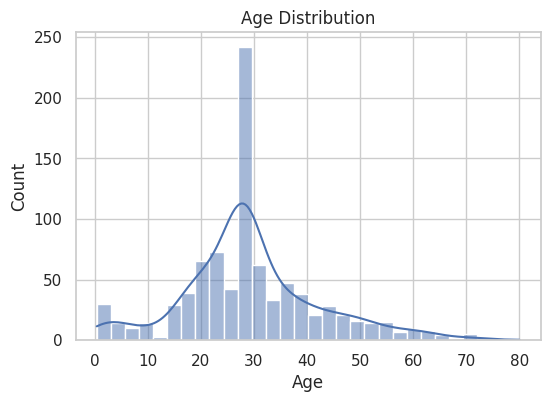

In [8]:
# Age distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


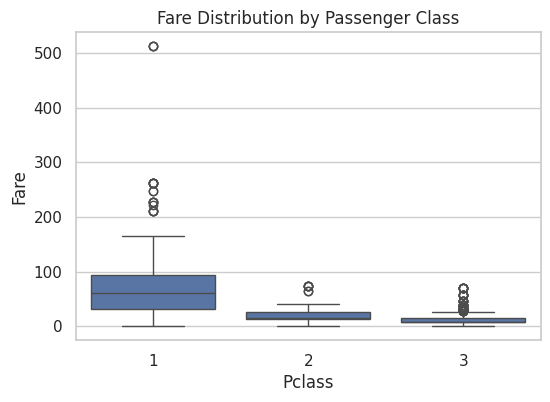

In [9]:
# Fare by Passenger Class
plt.figure(figsize=(6,4))
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare Distribution by Passenger Class")
plt.show()


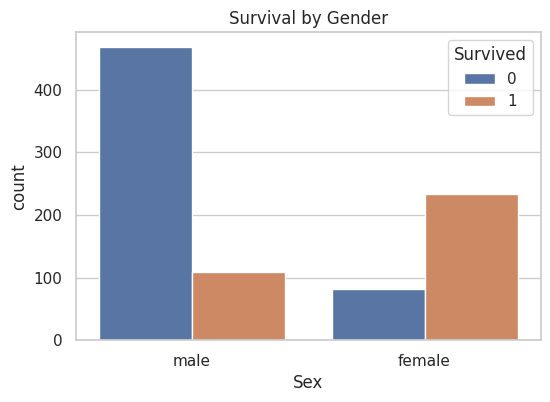

In [10]:
# Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()


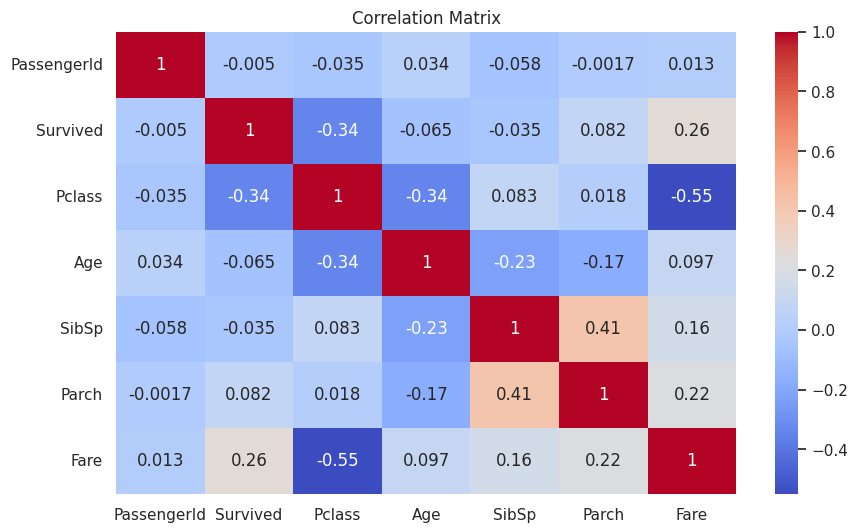

In [11]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [12]:
# Survival percentage by class
pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100


Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


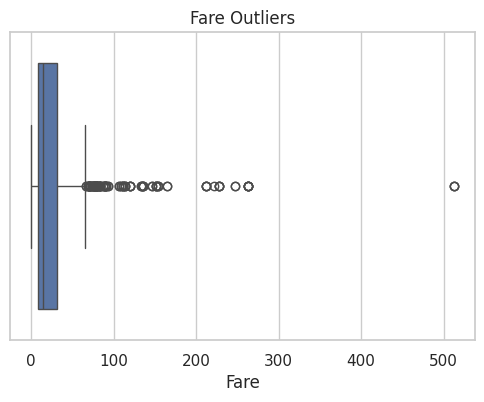

In [13]:
# Boxplot to detect fare outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()


In [14]:
# Z-score method for outlier detection
from scipy import stats

z_scores = np.abs(stats.zscore(df["Fare"]))
outliers = df[z_scores > 3]

print("Number of Fare Outliers:", len(outliers))


Number of Fare Outliers: 20


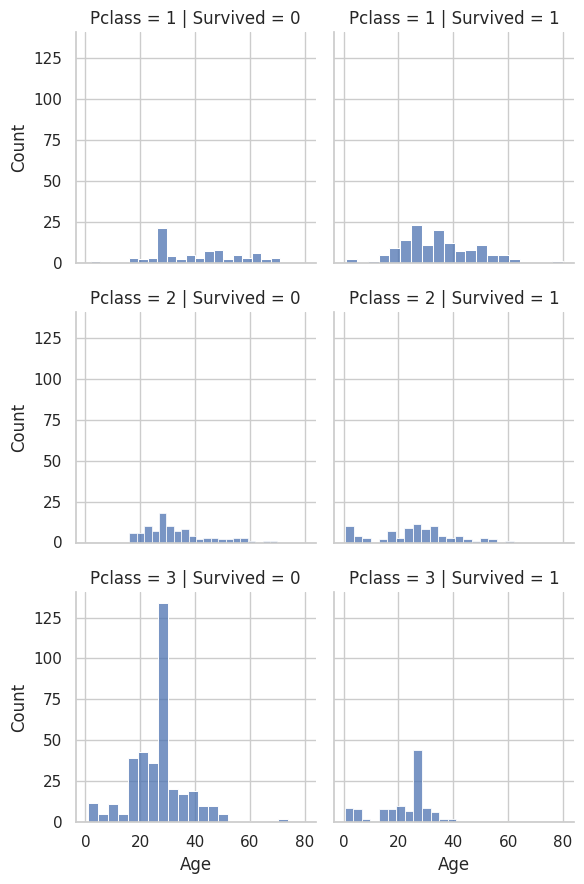

In [15]:
# Facet analysis: Age vs Survival & Class
g = sns.FacetGrid(df, col="Survived", row="Pclass", height=3)
g.map(sns.histplot, "Age", bins=20)
plt.show()


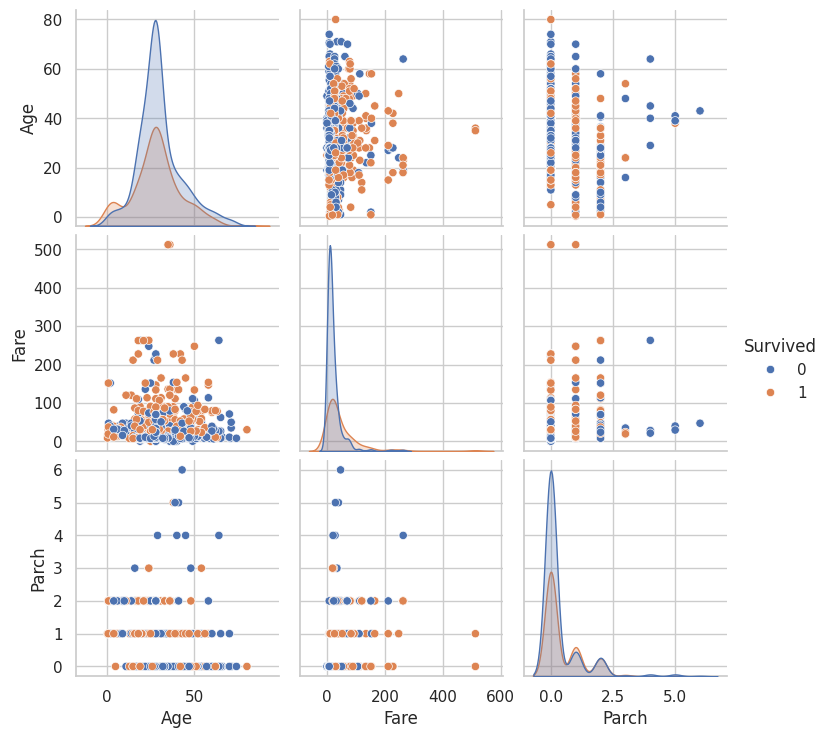

In [16]:
# Pairplot for multivariate analysis
sns.pairplot(df[["Age", "Fare", "Parch", "Survived"]], hue="Survived")
plt.show()


INSIGHTS:
1. Females had higher survival rates than males.
2. 1st class passengers survived more than 3rd class.
3. Fare shows positive correlation with survival.
4. Survival probability peaks for age group 20–40.
5. High fare outliers are legitimate first-class passengers.
